## 1. Persiapan Library dan Dataset
Melakukan import library-library yang diperlukan seperti pandas, numpy, matpotlib, seaborn, dan sklearn. Setelah itu melakukan import file csv yang dibutuhkan kemudian dilakukan perintah .head, .info, .shape, dan .describe untuk memahami data. Setelah itu dilakukan beberapa EDA seperti melihat korelasi atribut ke target dan distribusi target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

In [3]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('train.csv')
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


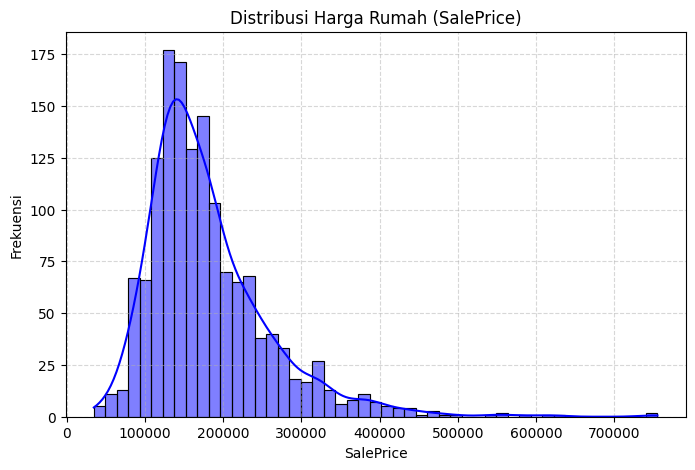

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('Distribusi Harga Rumah (SalePrice)')
plt.xlabel('SalePrice')
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

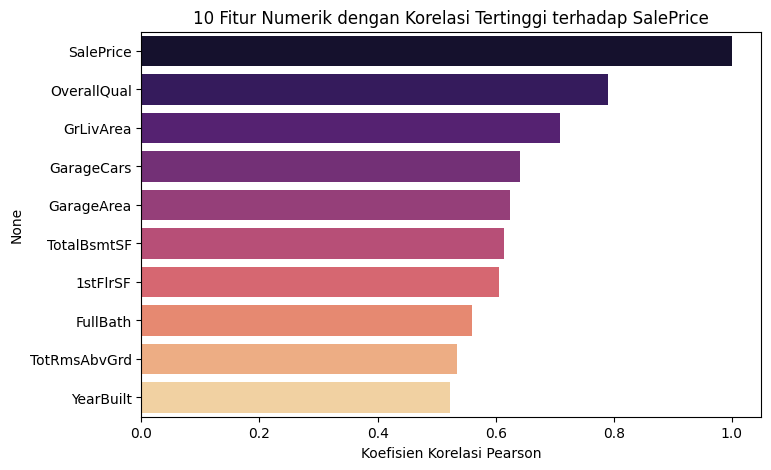

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [ ]:
# Analisis Korelasi Fitur Numerik terhadap SalePrice
numeric_df = df.select_dtypes(include=[np.number])
top_corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='magma', hue=top_corr.index, legend=False)
plt.title('10 Fitur Numerik dengan Korelasi Tertinggi terhadap SalePrice')
plt.xlabel('Koefisien Korelasi Pearson')
plt.show()

print(top_corr)

## 2. Pembersihan Data
Melakukan pengecekan terhadap missing values yang terdapat pada dataset kemudian dilakukan beberapa proses yaitu membuang kolom dengan missing values diatas 50% dan imputasi nilai missing values yang tersisa.

In [9]:
# Menghitung persentase nilai yang hilang per kolom
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': df.isnull().sum(), 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Percentage', ascending=False)
missing_df.head(10)

,Missing_Count,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


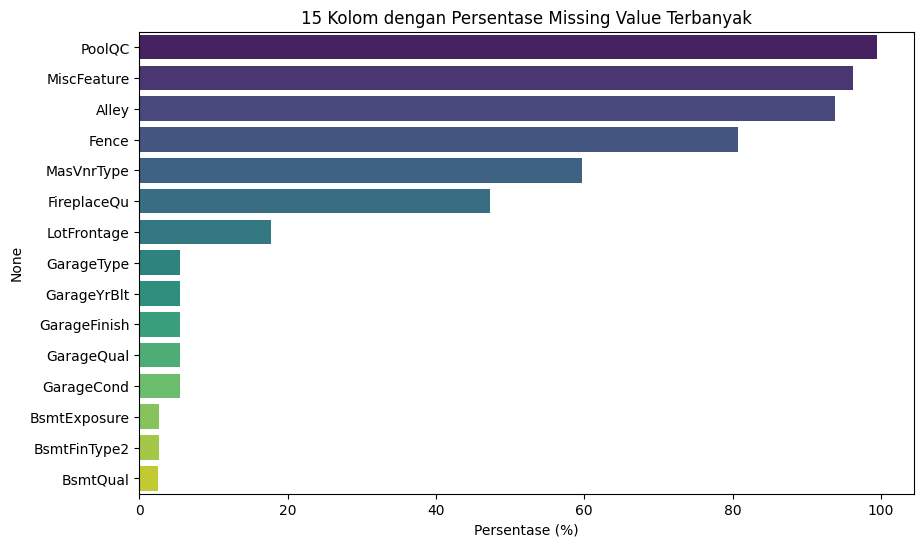

In [10]:
# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_df['Percentage'][:15], 
    y=missing_df.index[:15], 
    hue=missing_df.index[:15], 
    palette='viridis', 
    legend=False
)
plt.title('15 Kolom dengan Persentase Missing Value Terbanyak')
plt.xlabel('Persentase (%)')
plt.show()


In [ ]:
# Kolom dengan missing value > 50%
cols_to_drop = missing_percent[missing_percent > 50].index.tolist()
print("Kolom yang dihapus (> 50% missing values):", cols_to_drop)

df_clean = df.drop(columns=cols_to_drop + ['Id']) # 'Id' juga dihapus karena hanya identifier

Kolom yang dihapus (> 50% missing values): ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']


In [15]:
# Memisahkan kolom numerik dan kategorikal
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()

# Imputasi kolom numerik dengan median
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Imputasi kolom kategorikal dengan modus
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Sisa missing value setelah imputasi:", df_clean.isnull().sum().sum())

Sisa missing value setelah imputasi: 0


## 3. Deteksi Outlier
Melakukan deteksi outlier pada dataset tetapi yang ditampilkan pada boxplot hanya beberapa karena atribut terlalu banyak. Setelah itu dilakukan teknik cappping menggunakan IQR pada outlier karena demi menghindari pembuangan data berharga pada fitur utama.

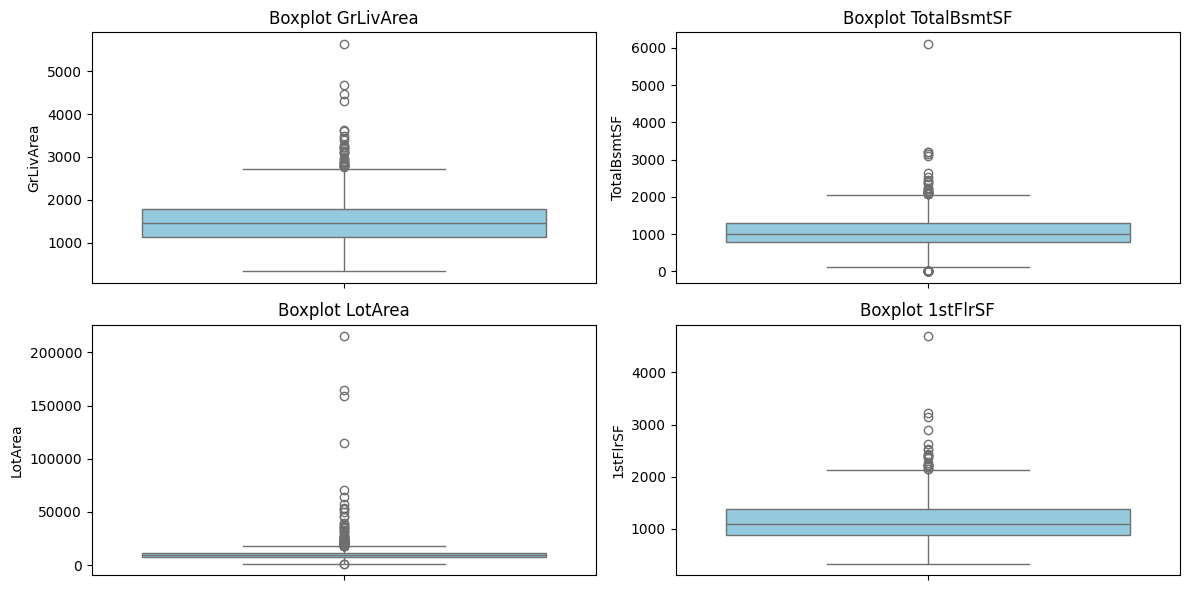

In [ ]:
num_features_to_check = ['GrLivArea', 'TotalBsmtSF', 'LotArea', '1stFlrSF']

plt.figure(figsize=(12, 6))
for i, col in enumerate(num_features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_clean[col], color='skyblue')
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

In [ ]:
# Menangani outlier dengan teknik Capping menggunakan IQR
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Melakukan capping
    df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, 
                             np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col]))

print("Outlier berhasil ditangani dengan metode Capping/Winsorization.")

Outlier berhasil ditangani dengan metode Capping/Winsorization.


## 4. Transformasi Data
Dilakukan normalisasi atribut dengan rincian atribut kategorikal menggunakan One-Hot Encoding dan atribut numerik distandarisasi menggunakan StandardScaler

In [ ]:
# Encoding atribut kategoris menggunakan One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print("Ukuran dataset setelah One-Hot Encoding:", df_encoded.shape)

Ukuran dataset setelah One-Hot Encoding: (1460, 234)


In [21]:
# Standarisasi fitur numerik (menggunakan StandardScaler)
X_num = df_encoded[num_cols].drop(columns=['SalePrice']) # Eksklusi target variabel 'SalePrice'

scaler = StandardScaler()
X_scaled_num = pd.DataFrame(scaler.fit_transform(X_num), columns=X_num.columns)

# Gabungkan kembali data numerik yang sudah di-scale dengan fitur encoded
df_transformed = df_encoded.copy()
df_transformed[X_num.columns] = X_scaled_num

## 5. Reduksi Dimensi
Menghitung nilai dengan korelasi yang tinggi diatas 0.80 kemudian dibuang salah satu untuk menghindari data redundan karena kemiripan yang tinggi kemudian digunakan PCA untuk mengurangi dimensi data. Hasil kemudian disimpan pada file csv baru dengan 43 PCA dan 1 atribut target

In [ ]:
# Menghitung matriks korelasi pada fitur numerik
corr_matrix = X_scaled_num.corr().abs()

# Mengidentifikasi pasangan fitur dengan korelasi di atas threshold (0.80)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]

print("Fitur dengan korelasi sangat tinggi (> 0.80):", high_corr_cols)

# Drop fitur yang multikolinearitas tinggi
df_reduced_corr = df_transformed.drop(columns=high_corr_cols)
print("Ukuran data setelah eliminasi korelasi tinggi:", df_reduced_corr.shape)

Fitur dengan korelasi sangat tinggi (> 0.80): ['1stFlrSF', 'TotRmsAbvGrd', 'GarageArea']
Ukuran data setelah eliminasi korelasi tinggi: (1460, 231)


In [ ]:
# Menerapkan PCA pada fitur independen
X = df_reduced_corr.drop(columns=['SalePrice'])
y = df_reduced_corr['SalePrice']
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X)

print("Jumlah komponen utama (PCA) yang dihasilkan:", pca.n_components_)
print("Total variance explained:", np.sum(pca.explained_variance_ratio_))

df_final = pd.DataFrame(X_pca, columns=[f'PC_{i+1}' for i in range(pca.n_components_)])
df_final['SalePrice'] = y.values

df_final.head()

Jumlah komponen utama (PCA) yang dihasilkan: 43
Total variance explained: 0.9011543347746562


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,PC_16,PC_17,PC_18,PC_19,PC_20,PC_21,PC_22,PC_23,PC_24,PC_25,PC_26,PC_27,PC_28,PC_29,PC_30,PC_31,PC_32,PC_33,PC_34,PC_35,PC_36,PC_37,PC_38,PC_39,PC_40,PC_41,PC_42,PC_43,SalePrice
0,2.430233,0.260611,-1.599412,-1.798784,0.883164,-1.762907,-0.506578,-1.442465,-0.626521,-0.344102,-1.038935,-0.220583,-0.006562,0.471135,-0.873323,-0.229260,-0.165870,0.040126,-0.836830,-0.219049,-0.080279,0.090862,-0.412045,0.387716,-0.026331,0.073407,0.347884,-0.247138,0.284819,0.132736,0.153862,0.045890,-0.232683,-0.081934,-0.074381,-0.033476,0.048096,0.128322,0.185314,0.090810,0.104860,0.037803,0.170552,208500.0
1,-0.141502,-1.442216,1.481287,-0.009761,1.099381,0.873410,0.044816,1.867514,0.640850,-0.338278,-1.065612,0.019912,-1.329773,-0.672678,0.292557,0.692003,-0.911810,-1.289481,-0.292338,-0.368829,1.234926,0.479961,0.856404,0.195645,-0.176161,-0.133803,0.157719,0.609216,-0.839121,-0.530191,0.291086,-0.256710,-0.131371,-0.149280,0.103977,0.898586,-0.062797,1.131130,0.400476,0.020016,-0.707014,0.334655,0.037681,181500.0
2,2.998348,0.560550,-0.649765,-1.345754,0.010514,-0.378814,-1.145722,-0.299037,-0.003102,0.277661,0.812795,-1.302176,-0.241615,0.536265,-0.619135,-0.451778,0.132041,0.949603,-0.975932,-0.154417,0.088474,0.028847,0.079477,0.318718,-0.039664,0.058680,0.113706,-0.101023,-0.007220,0.224322,0.116655,-0.698632,0.053662,-0.333824,-0.242821,0.069022,-0.021039,0.468636,-0.617326,-0.052055,-0.103794,0.119319,-0.293529,223500.0
3,-0.575073,0.977255,0.342536,-0.616439,-0.559435,0.197803,0.171172,-0.647609,-0.046881,-2.272164,-1.151512,-0.851897,1.489891,-0.406007,0.011362,0.942081,-0.427302,1.176261,0.409135,0.910063,-1.016286,0.406755,0.373637,0.319476,0.530973,1.439408,-0.447270,0.667619,0.801727,-0.192434,-0.520462,-0.044777,0.471775,0.515816,0.104452,-0.899716,0.074860,0.006676,0.605544,0.220770,0.378775,-0.945967,1.000519,140000.0
4,5.023555,1.006597,1.139949,-1.323301,-0.459013,0.090567,-1.170222,0.246616,-0.311150,1.603101,0.572766,-0.160259,0.496183,-0.197137,-0.444475,-0.108743,-0.165416,1.331624,-1.148512,0.318058,0.094196,-0.202819,0.241574,-0.044859,-0.148352,0.208653,0.056356,0.411092,-0.005950,-0.467476,0.412236,-0.042934,-0.035677,0.046744,0.063682,0.115766,0.005853,0.404952,-0.451274,-0.071040,0.067504,0.081347,0.071086,250000.0


In [ ]:
df_final.to_csv('5054251006_Fasya_Tugas_Praproses_Data.csv', index=False)
print("Dataset akhir berhasil disimpan dengan nama 5054251006_Fasya_Tugas_Praproses_Data.csv!")

Dataset akhir berhasil disimpan dengan nama 5054251006_Fasya_Tugas_Praproses_Data_fix.csv!
